In [ ]:
import os
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box
from shapely.wkt import loads
from shapely.ops import unary_union
from shapely import box as sbox

pd.set_option('display.max_columns', None)

# ── CRS ───────────────────────────────────────────────────────────────────
CRS_VICGRID = "EPSG:7899"   # GDA2020 / VicGrid — metres, Victoria
CRS_WGS84   = "EPSG:4326"   # Output CRS for centroid lon/lat

# ── Grid configuration ────────────────────────────────────────────────────
# Change CELL_SIZE_M to regenerate the grid at any resolution.
# Common values:
#   250  → ~250 m  (FireFusion schema default, ~180,000 cells over Victoria)
#   500  → ~500 m  (faster for dev/testing, ~45,000 cells)
#   1000 → ~1 km   (coarse overview, ~11,000 cells)
CELL_SIZE_M = 5000

# ── File paths ────────────────────────────────────────────────────────────
GRID_FILE    = f"../../src/data/victoria_grid_{CELL_SIZE_M}m.geojson"


# ── Cell ID prefix ────────────────────────────────────────────────────────
# Format: VIC_{CELL_SIZE_M}M_{ROW:05d}_{COL:05d}
# e.g.   VIC_500M_00142_00087
CELL_ID_PREFIX = f"VIC_{CELL_SIZE_M}M"

print(f"Config loaded.")
print(f"  CRS        : {CRS_VICGRID}")
print(f"  Cell size  : {CELL_SIZE_M} m")
print(f"  Grid file  : {GRID_FILE}")
print(f"  Cell prefix: {CELL_ID_PREFIX}")
# ── Victoria boundary — embedded WKT (EPSG:7899 VicGrid) ──────────────────
# Approximate boundary sufficient for grid clipping. Traced from major
# geographic features: Murray River (N), SA border (W), NSW border (NE),
# Bass Strait coastline (S).
#
# To use the full high-resolution ABS boundary instead, place
# victoria_boundary.geojson in src/data/ and uncomment:
#   vic_wgs84 = gpd.read_file("../../src/data/victoria_boundary.geojson")
#   vic = vic_wgs84.to_crs(CRS_VICGRID)
#   vic_union = unary_union(vic.geometry)

VIC_BOUNDARY_WKT = (
    "POLYGON (("
    "2145693.020715848 2375515.0489793825, "
    "2143109.3338525863 2436391.6201346605, "
    "2138399.468741087 2547364.9902705336, "
    "2135999.9590507345 2603901.997320252, "
    "2131294.3782136436 2714774.4218115103, "
    "2180394.766949665 2716719.3379330286, "
    "2271685.355684544 2719597.0933194906, "
    "2363176.005597993 2710418.2954275324, "
    "2454565.1868934035 2678082.9308495983, "
    "2545259.967221889 2644792.5628925827, "
    "2635250.4251612867 2610557.312791315, "
    "2724526.756339845 2575387.4016869124, "
    "2768509.541209139 2545256.1001236998, "
    "2793658.2303635012 2495575.592823826, "
    "2810224.3177361246 2461673.2788919555, "
    "2896179.2679352304 2402523.181311338, "
    "2939789.335348821 2433686.134948229, "
    "2945440.53786627 2433388.5788345397, "
    "2893766.6597477975 2351521.1071937406, "
    "2805899.974955606 2344104.092179051, "
    "2718232.581912183 2335760.2112474144, "
    "2630249.3879640964 2293184.25046347, "
    "2543476.3838308146 2305201.2280950937, "
    "2456348.667361446 2338511.1924275616, "
    "2369575.645566607 2304287.8759665764, "
    "2282933.65494364 2291360.097402428, "
    "2194916.193859134 2321914.2916382793, "
    "2145693.020715848 2375515.0489793825"
    "))"
)

vic_union = loads(VIC_BOUNDARY_WKT)
vic = gpd.GeoDataFrame(geometry=[vic_union], crs=CRS_VICGRID)

minx, miny, maxx, maxy = vic_union.bounds
print(f"Victoria bounds (VicGrid metres):")
print(f"  X: {minx:,.0f} → {maxx:,.0f}  (span: {(maxx-minx)/1000:,.1f} km)")
print(f"  Y: {miny:,.0f} → {maxy:,.0f}  (span: {(maxy-miny)/1000:,.1f} km)")
# ── Victoria boundary — embedded WKT (EPSG:7899 VicGrid) ──────────────────
# Approximate boundary sufficient for grid clipping. Traced from major
# geographic features: Murray River (N), SA border (W), NSW border (NE),
# Bass Strait coastline (S).
#
# To use the full high-resolution ABS boundary instead, place
# victoria_boundary.geojson in src/data/ and uncomment:
#   vic_wgs84 = gpd.read_file("../../src/data/victoria_boundary.geojson")
#   vic = vic_wgs84.to_crs(CRS_VICGRID)
#   vic_union = unary_union(vic.geometry)

VIC_BOUNDARY_WKT = (
    "POLYGON (("
    "2145693.020715848 2375515.0489793825, "
    "2143109.3338525863 2436391.6201346605, "
    "2138399.468741087 2547364.9902705336, "
    "2135999.9590507345 2603901.997320252, "
    "2131294.3782136436 2714774.4218115103, "
    "2180394.766949665 2716719.3379330286, "
    "2271685.355684544 2719597.0933194906, "
    "2363176.005597993 2710418.2954275324, "
    "2454565.1868934035 2678082.9308495983, "
    "2545259.967221889 2644792.5628925827, "
    "2635250.4251612867 2610557.312791315, "
    "2724526.756339845 2575387.4016869124, "
    "2768509.541209139 2545256.1001236998, "
    "2793658.2303635012 2495575.592823826, "
    "2810224.3177361246 2461673.2788919555, "
    "2896179.2679352304 2402523.181311338, "
    "2939789.335348821 2433686.134948229, "
    "2945440.53786627 2433388.5788345397, "
    "2893766.6597477975 2351521.1071937406, "
    "2805899.974955606 2344104.092179051, "
    "2718232.581912183 2335760.2112474144, "
    "2630249.3879640964 2293184.25046347, "
    "2543476.3838308146 2305201.2280950937, "
    "2456348.667361446 2338511.1924275616, "
    "2369575.645566607 2304287.8759665764, "
    "2282933.65494364 2291360.097402428, "
    "2194916.193859134 2321914.2916382793, "
    "2145693.020715848 2375515.0489793825"
    "))"
)

vic_union = loads(VIC_BOUNDARY_WKT)
vic = gpd.GeoDataFrame(geometry=[vic_union], crs=CRS_VICGRID)

minx, miny, maxx, maxy = vic_union.bounds
print(f"Victoria bounds (VicGrid metres):")
print(f"  X: {minx:,.0f} → {maxx:,.0f}  (span: {(maxx-minx)/1000:,.1f} km)")
print(f"  Y: {miny:,.0f} → {maxy:,.0f}  (span: {(maxy-miny)/1000:,.1f} km)")
def generate_grid(
    boundary_geom,
    cell_size: int,
    crs: str,
) -> gpd.GeoDataFrame:
    """
    Generate a uniform square grid clipped to boundary_geom.

    Parameters
    ----------
    boundary_geom : shapely geometry
        State boundary polygon in the target CRS.
    cell_size : int
        Cell side length in metres.
    crs : str
        EPSG string of the projected CRS (must be in metres).

    Returns
    -------
    GeoDataFrame with columns: row, col, geometry (cell polygon)
    """
    minx, miny, maxx, maxy = boundary_geom.bounds

    # Snap origin to grid so cell edges land on round metre values
    origin_x = np.floor(minx / cell_size) * cell_size
    origin_y = np.floor(miny / cell_size) * cell_size

    cols = np.arange(origin_x, maxx + cell_size, cell_size)
    rows = np.arange(origin_y, maxy + cell_size, cell_size)

    print(f"  Grid extent : {len(cols)-1} cols × {len(rows)-1} rows"
          f" = {(len(cols)-1)*(len(rows)-1):,} candidate cells")

    # Build cell polygons — vectorised using numpy broadcasting
    col_idx, row_idx = np.meshgrid(
        np.arange(len(cols) - 1),
        np.arange(len(rows) - 1)
    )
    col_idx = col_idx.ravel()
    row_idx = row_idx.ravel()

    x0 = cols[col_idx]
    y0 = rows[row_idx]
    x1 = x0 + cell_size
    y1 = y0 + cell_size

    # shapely.box is vectorised in shapely 2.x
    from shapely import box as sbox
    geometries = sbox(x0, y0, x1, y1)

    gdf = gpd.GeoDataFrame(
        {"row": row_idx, "col": col_idx},
        geometry=geometries,
        crs=crs
    )

    # ── Clip: keep only cells that intersect the boundary ─────────────────
    print("  Clipping to Victoria boundary...")
    grid_clipped = gdf[gdf.intersects(boundary_geom)].copy()
    print(f"  Cells after clip: {len(grid_clipped):,}")

    return grid_clipped.reset_index(drop=True)


print(f"Generating {CELL_SIZE_M} m grid...")
grid = generate_grid(vic_union, CELL_SIZE_M, CRS_VICGRID)
print(f"\nGrid generated: {len(grid):,} cells")

Config loaded.
  CRS        : EPSG:7899
  Cell size  : 5000 m
  Grid file  : ../../src/data/victoria_grid_5000m.geojson
  Cell prefix: VIC_5000M


## 4. Cell ID Assignment
Assigns a unique, deterministic `cell_id` to each cell using the format:

```
VIC_{CELL_SIZE}M_{ROW:05d}_{COL:05d}
```

**Row/col** are zero-indexed from the south-west corner of the grid bounding box,  
so `ROW=00000, COL=00000` is the bottom-left cell.  

IDs are **stable across runs** — same cell size always produces the same ID  
for the same geographic cell because they are derived from the snapped grid  
origin, not from array position after clipping.

Also computes:
- `centroid_lon`, `centroid_lat` — WGS84 centroid (EPSG:7855 method for accuracy)
- `cell_area_ha` — actual cell area in hectares (accounts for boundary-clipped edge cells)

In [4]:
# ── cell_id ───────────────────────────────────────────────────────────────
# Format: VIC_{CELL_SIZE}M_{ROW:05d}_{COL:05d}
# Row/col zero-indexed from SW corner — stable across runs for same cell size.
grid["cell_id"] = (
    CELL_ID_PREFIX + "_"
    + grid["row"].apply(lambda r: f"{r:05d}")
    + "_"
    + grid["col"].apply(lambda c: f"{c:05d}")
)

assert grid["cell_id"].nunique() == len(grid), "Duplicate cell_ids detected!"
print(f"✓ All {len(grid):,} cell_ids are unique.")
print(f"  Sample IDs: {grid['cell_id'].iloc[:3].tolist()}")

# ── Accurate centroids ────────────────────────────────────────────────────
# VicGrid (7899) → EPSG:7855 (MGA zone 55, metres) → centroid → WGS84
# Consistent with the Fire History centroid methodology from Week 3.
centroids_mga = (
    grid.to_crs("EPSG:7855")
        .geometry
        .centroid
        .pipe(lambda s: gpd.GeoSeries(s, crs="EPSG:7855"))
        .to_crs(CRS_WGS84)
)
grid["centroid_lon"] = centroids_mga.x.round(6)
grid["centroid_lat"] = centroids_mga.y.round(6)

# ── Cell area in hectares ─────────────────────────────────────────────────
# Full interior cells = CELL_SIZE_M² / 10000 ha exactly.
# Edge cells clipped to the boundary will be smaller.
grid["cell_area_ha"] = (grid.geometry.area / 10_000).round(4)

full_area_ha = (CELL_SIZE_M ** 2) / 10_000
edge_cells   = (grid["cell_area_ha"] < full_area_ha * 0.99).sum()

print(f"\nCell area summary:")
print(f"  Full cells ({full_area_ha:.1f} ha) : {len(grid) - edge_cells:,}")
print(f"  Edge cells (partial)      : {edge_cells:,}")
print(f"  Total grid area           : {grid['cell_area_ha'].sum():,.0f} ha")
print(f"\nSample rows:")
print(grid[["cell_id", "row", "col", "centroid_lon",
            "centroid_lat", "cell_area_ha"]].head(5).to_string(index=False))

✓ All 9,645 cell_ids are unique.
  Sample IDs: ['VIC_5000M_00000_00028', 'VIC_5000M_00000_00029', 'VIC_5000M_00000_00030']

Cell area summary:
  Full cells (2500.0 ha) : 9,645
  Edge cells (partial)      : 0
  Total grid area           : 24,112,500 ha

Sample rows:
              cell_id  row  col  centroid_lon  centroid_lat  cell_area_ha
VIC_5000M_00000_00028    0   28    142.380254    -38.841213        2500.0
VIC_5000M_00000_00029    0   29    142.437802    -38.842438        2500.0
VIC_5000M_00000_00030    0   30    142.495353    -38.843636        2500.0
VIC_5000M_00000_00031    0   31    142.552905    -38.844807        2500.0
VIC_5000M_00000_00032    0   32    142.610460    -38.845951        2500.0


## 5. Validation & Export
Visual sanity check followed by export to GeoJSON and Parquet.  

- **GeoJSON** — interoperable, used by downstream ETL and the FireFusion schema


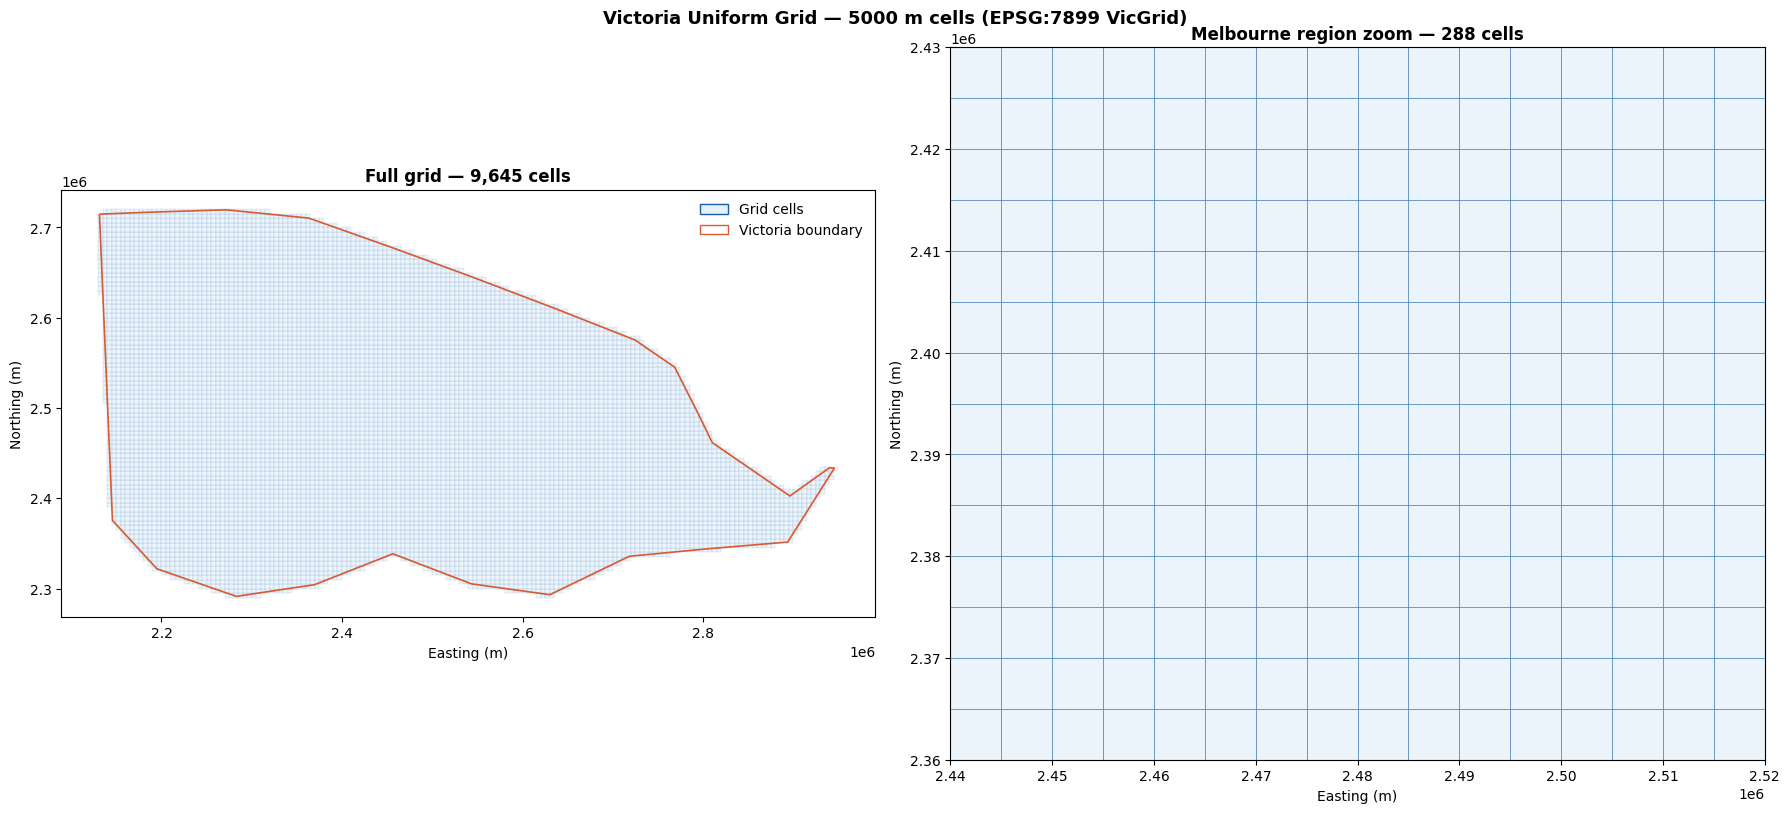

Saved → ../../src/data/victoria_grid_5000m_validation.png


In [5]:
# ── Visual validation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    f"Victoria Uniform Grid — {CELL_SIZE_M} m cells (EPSG:7899 VicGrid)",
    fontsize=13, fontweight="bold"
)

# Plot 1: Full grid overview
ax = axes[0]
grid.plot(
    ax=ax,
    facecolor="#E6F1FB",
    edgecolor="#185FA5",
    linewidth=0.1,
    alpha=0.7
)
vic.boundary.plot(ax=ax, color="#D85A30", linewidth=1.2)
ax.set_title(f"Full grid — {len(grid):,} cells", fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="sci", scilimits=(0, 0))
ax.legend(handles=[
    mpatches.Patch(facecolor="#E6F1FB", edgecolor="#185FA5", label="Grid cells"),
    mpatches.Patch(facecolor="none",    edgecolor="#D85A30", label="Victoria boundary"),
], frameon=False)

# Plot 2: Melbourne region zoom
ax = axes[1]
melb_bounds = (2_440_000, 2_360_000, 2_520_000, 2_430_000)
grid_melb = grid.cx[
    melb_bounds[0]:melb_bounds[2],
    melb_bounds[1]:melb_bounds[3]
]
grid_melb.plot(
    ax=ax,
    facecolor="#E6F1FB",
    edgecolor="#185FA5",
    linewidth=0.4,
    alpha=0.8
)
vic.boundary.plot(ax=ax, color="#D85A30", linewidth=1.0)
ax.set_xlim(melb_bounds[0], melb_bounds[2])
ax.set_ylim(melb_bounds[1], melb_bounds[3])
ax.set_title(f"Melbourne region zoom — {len(grid_melb):,} cells", fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.savefig(
    f"../../src/data/victoria_grid_{CELL_SIZE_M}m_validation.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Saved → ../../src/data/victoria_grid_{CELL_SIZE_M}m_validation.png")

In [6]:
# ── Cell ID format check ───────────────────────────────────────────────────
import re
pattern = re.compile(rf"^{re.escape(CELL_ID_PREFIX)}_\d{{5}}_\d{{5}}$")
malformed = grid[~grid["cell_id"].str.match(pattern)]
if len(malformed) == 0:
    print(f"✓ All cell_ids match format: {CELL_ID_PREFIX}_RRRRR_CCCCC")
else:
    print(f"⚠  {len(malformed)} malformed cell_ids detected:")
    print(malformed["cell_id"].head())

# ── Centroid bounds check ─────────────────────────────────────────────────
vic_lon_range = (140.9, 150.1)
vic_lat_range = (-39.3, -33.9)
lon_ok = grid["centroid_lon"].between(*vic_lon_range).all()
lat_ok = grid["centroid_lat"].between(*vic_lat_range).all()
print(f"{'✓' if lon_ok else '⚠'} All centroid longitudes within Victoria bounds {vic_lon_range}")
print(f"{'✓' if lat_ok else '⚠'} All centroid latitudes  within Victoria bounds {vic_lat_range}")

# ── Coverage check ────────────────────────────────────────────────────────
vic_area_ha = vic_union.area / 10_000
grid_area_ha = grid["cell_area_ha"].sum()
coverage_pct = (grid_area_ha / vic_area_ha) * 100
print(f"\nVictoria area    : {vic_area_ha:,.0f} ha")
print(f"Grid total area  : {grid_area_ha:,.0f} ha")
print(f"Coverage         : {coverage_pct:.1f}%  (expect ~100% — edge cells partially outside)")

✓ All cell_ids match format: VIC_5000M_RRRRR_CCCCC
✓ All centroid longitudes within Victoria bounds (140.9, 150.1)
✓ All centroid latitudes  within Victoria bounds (-39.3, -33.9)

Victoria area    : 23,445,496 ha
Grid total area  : 24,112,500 ha
Coverage         : 102.8%  (expect ~100% — edge cells partially outside)


In [ ]:
# ── Export columns ─────────────────────────────────────────────────────────
EXPORT_COLS = [
    "cell_id",         # unique identifier — FireFusion schema primary key
    "row",             # grid row index from SW origin
    "col",             # grid col index from SW origin
    "centroid_lon",    # WGS84 longitude — used for weather API calls
    "centroid_lat",    # WGS84 latitude  — used for weather API calls
    "cell_area_ha",    # actual area (edge cells < CELL_SIZE_M²)
    "geometry",        # cell polygon in EPSG:7899
]
grid_export = grid[EXPORT_COLS].copy()

# ── GeoJSON export ────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(GRID_FILE), exist_ok=True)
grid_export.to_file(GRID_FILE, driver="GeoJSON")
size_mb = os.path.getsize(GRID_FILE) / 1_048_576
print(f"GeoJSON saved  → {GRID_FILE}  ({size_mb:.1f} MB)")


# ── Final summary ─────────────────────────────────────────────────────────
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Grid generation complete
  Cell size   : {CELL_SIZE_M} m × {CELL_SIZE_M} m
  CRS         : {CRS_VICGRID} (GDA2020/VicGrid)
  Total cells : {len(grid_export):,}
  Cell ID fmt : {CELL_ID_PREFIX}_RRRRR_CCCCC
  Centroid CRS: {CRS_WGS84} (WGS84)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

GeoJSON saved  → ../../src/data/victoria_grid_5000m.geojson  (3.4 MB)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Grid generation complete
  Cell size   : 5000 m × 5000 m
  CRS         : EPSG:7899 (GDA2020/VicGrid)
  Total cells : 9,645
  Cell ID fmt : VIC_5000M_RRRRR_CCCCC
  Centroid CRS: EPSG:4326 (WGS84)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

